# **Customer Segmentation with Unsupervised Clustering**

# import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler ,RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# *read Data*

In [3]:
df = pd.read_csv("/content/drive/MyDrive/CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
for col in df.columns:
  print(col , "=>", len(df[col].unique()))

CUST_ID => 8950
BALANCE => 8871
BALANCE_FREQUENCY => 43
PURCHASES => 6203
ONEOFF_PURCHASES => 4014
INSTALLMENTS_PURCHASES => 4452
CASH_ADVANCE => 4323
PURCHASES_FREQUENCY => 47
ONEOFF_PURCHASES_FREQUENCY => 47
PURCHASES_INSTALLMENTS_FREQUENCY => 47
CASH_ADVANCE_FREQUENCY => 54
CASH_ADVANCE_TRX => 65
PURCHASES_TRX => 173
CREDIT_LIMIT => 206
PAYMENTS => 8711
MINIMUM_PAYMENTS => 8637
PRC_FULL_PAYMENT => 47
TENURE => 7


In [5]:
len(df.columns)

18

# *EDA*

In [6]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [7]:
df.shape

(8950, 18)

In [8]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [9]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mode()[0])
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean())

In [10]:
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop('CUST_ID',axis=1,inplace=True)

In [13]:
len(df.columns)

17

# *Some Visualization*

<Axes: >

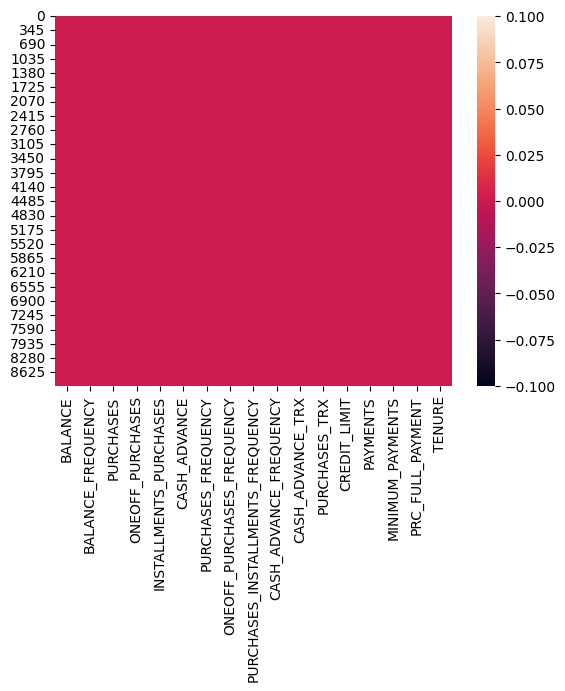

In [15]:
sns.heatmap(df.isnull())

<Axes: ylabel='CREDIT_LIMIT'>

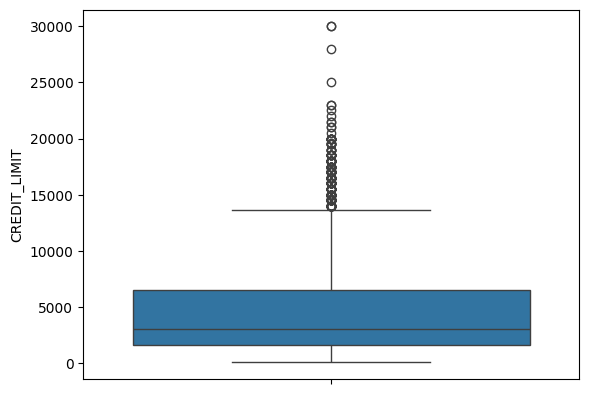

In [ ]:
sns.boxplot(df["CREDIT_LIMIT"])

# Modelling

In [16]:
rb = RobustScaler()
df_rb = rb.fit_transform(df)

In [17]:
# Elbow Method: Find optimal number of clusters
inertias = []
silhouette_scores = []
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_rb)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_rb, kmeans.labels_))

print("Silhouette Scores for different k values:")
for k, score in zip(cluster_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

Silhouette Scores for different k values:
k=2: 0.6631
k=3: 0.5601
k=4: 0.3068
k=5: 0.3060
k=6: 0.2697
k=7: 0.2918
k=8: 0.2978
k=9: 0.2804
k=10: 0.2797


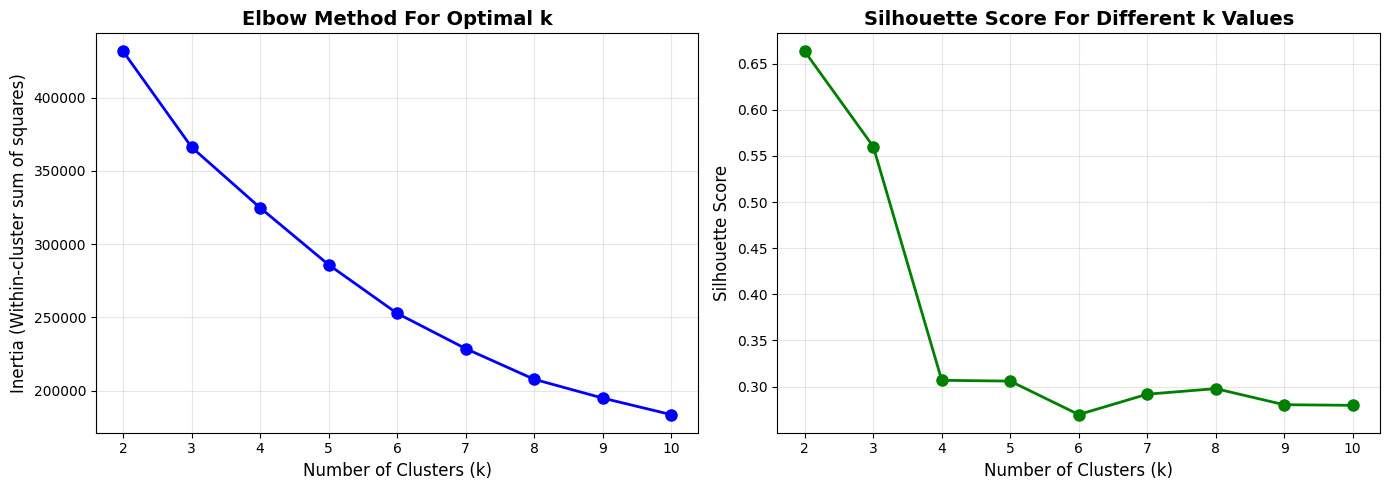


Optimal number of clusters based on Silhouette Score: 2


In [18]:
# Visualize Elbow Method and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(cluster_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette score plot
axes[1].plot(cluster_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score For Different k Values', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find k with highest silhouette score
optimal_k = cluster_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters based on Silhouette Score: {optimal_k}")

# Cluster Analysis and Profiling

In [19]:
# Fit final K-Means model with optimal k
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(df_rb)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

print(f"K-Means model fitted with {optimal_k} clusters")
print(f"Final Silhouette Score: {silhouette_score(df_rb, cluster_labels):.4f}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

K-Means model fitted with 2 clusters
Final Silhouette Score: 0.6631

Cluster distribution:
Cluster
0     372
1    8578
Name: count, dtype: int64


In [21]:
# Cluster Profiling: Compute mean values per cluster
cluster_profiles = df.groupby('Cluster').mean()
print("Cluster Profiles (Mean Values):")
print(cluster_profiles)

Cluster Profiles (Mean Values):
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        4287.491178           0.985221  7278.796210       4912.116129   
1        1446.386452           0.872589   731.052818        405.106933   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                   2366.680081   1737.580503             0.832392   
1                    326.259085    945.968350             0.475517   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                          0.583945                          0.676498   
1                          0.185914                          0.350904   

         CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  \
Cluster                      

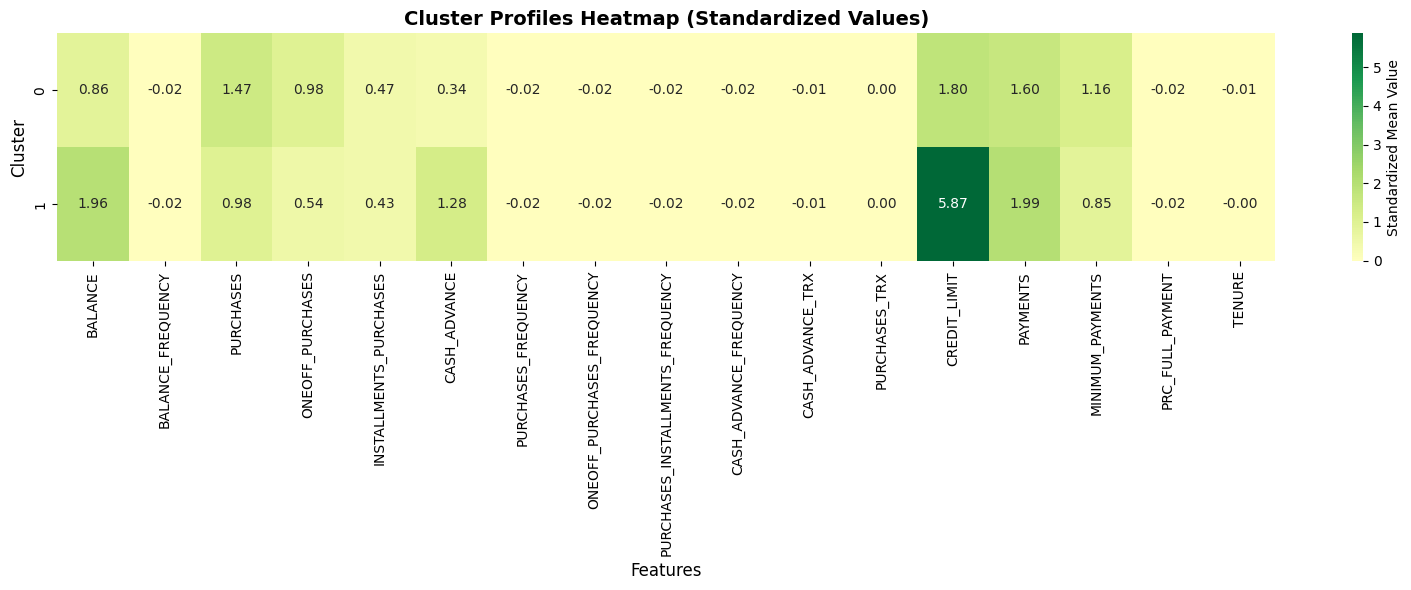

In [23]:
cluster_profiles_scaled = pd.DataFrame(
    rb.fit_transform(cluster_profiles.T).T,
    columns=cluster_profiles.columns
)

plt.figure(figsize=(16, 6))
sns.heatmap(cluster_profiles_scaled, annot=True, fmt='.2f', cmap='RdYlGn', center=0, cbar_kws={'label': 'Standardized Mean Value'})
plt.title('Cluster Profiles Heatmap (Standardized Values)', fontsize=14, fontweight='bold')
plt.ylabel('Cluster', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Cluster Visualization Using PCA

PCA Explained Variance Ratio: [0.30267501 0.24562999]
Total Variance Explained: 0.5483


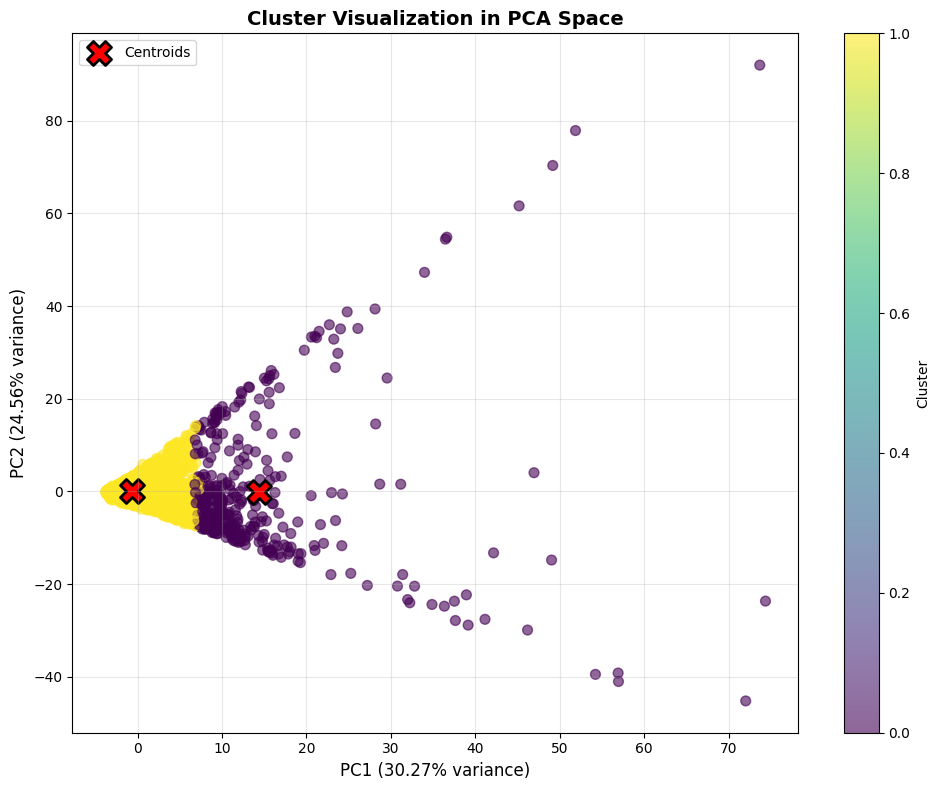

In [24]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_rb)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.4f}")

# Plot clusters in PCA space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=50)
plt.scatter(pca.transform(final_kmeans.cluster_centers_)[:, 0],
            pca.transform(final_kmeans.cluster_centers_)[:, 1],
            c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Cluster Visualization in PCA Space', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Business Interpretation and Cluster Naming

In [25]:
# Identify top distinguishing features for each cluster
print("="*80)
print("CLUSTER INSIGHTS AND BUSINESS INTERPRETATION")
print("="*80)

for cluster_id in range(optimal_k):
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster_id} - Analysis")
    print(f"{'='*80}")
    print(f"Size: {len(df[df['Cluster']==cluster_id])} customers ({len(df[df['Cluster']==cluster_id])/len(df)*100:.1f}%)")


    cluster_features = cluster_profiles.loc[cluster_id]


    overall_mean = df.iloc[:, :-1].mean()
    differences = cluster_features - overall_mean

    top_high = differences.nlargest(3)
    top_low = differences.nsmallest(3)

    print("\nTop 3 Distinguishing High Features (vs. overall average):")
    for feature, diff in top_high.items():
        print(f"  • {feature}: {cluster_features[feature]:.2f} (avg: {overall_mean[feature]:.2f}, diff: +{diff:.2f})")

    print("\nTop 3 Distinguishing Low Features (vs. overall average):")
    for feature, diff in top_low.items():
        print(f"  • {feature}: {cluster_features[feature]:.2f} (avg: {overall_mean[feature]:.2f}, diff: {diff:.2f})")

CLUSTER INSIGHTS AND BUSINESS INTERPRETATION

CLUSTER 0 - Analysis
Size: 372 customers (4.2%)

Top 3 Distinguishing High Features (vs. overall average):
  • PURCHASES: 7278.80 (avg: 1003.20, diff: +6275.59)
  • PAYMENTS: 7910.35 (avg: 1733.14, diff: +6177.20)
  • MINIMUM_PAYMENTS: 5786.52 (avg: 844.45, diff: +4942.07)

Top 3 Distinguishing Low Features (vs. overall average):
  • CASH_ADVANCE_FREQUENCY: 0.13 (avg: 0.14, diff: -0.00)
  • PRC_FULL_PAYMENT: 0.22 (avg: 0.15, diff: 0.07)
  • BALANCE_FREQUENCY: 0.99 (avg: 0.88, diff: 0.11)

CLUSTER 1 - Analysis
Size: 8578 customers (95.8%)

Top 3 Distinguishing High Features (vs. overall average):
  • CASH_ADVANCE_FREQUENCY: 0.14 (avg: 0.14, diff: +0.00)
  • PRC_FULL_PAYMENT: 0.15 (avg: 0.15, diff: +-0.00)
  • BALANCE_FREQUENCY: 0.87 (avg: 0.88, diff: +-0.00)

Top 3 Distinguishing Low Features (vs. overall average):
  • PURCHASES: 731.05 (avg: 1003.20, diff: -272.15)
  • PAYMENTS: 1465.26 (avg: 1733.14, diff: -267.89)
  • MINIMUM_PAYMENTS: 63